In [31]:
import urllib.request
import datetime
import json
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
def getRequestUrl(url): # API 요청하고 응답받는 함수
    try:
        response = urllib.request.urlopen(url)
        if response.getcode() == 200:
            print("[%s] Url Request Success" %datetime.datetime.now())
            return response.read().decode('utf-8')
    except Exception as e:
        print(e)
        print("[%s] Error for URL : %s" %(datetime.datetime.now(), url))
        return None

In [33]:
def getUsers_2022(key, pageNo, numOfRows):
    base = "https://api.odcloud.kr/api"

    parameters = "/15129481/v1/uddi:252b4b5b-7941-4488-8eca-96d61132ab4c?page=%s&perPage=%s&returnType=JSON&serviceKey=%s" % (pageNo, numOfRows, key)

    url = base + parameters
    responseDecode = getRequestUrl(url)

    if (responseDecode == None):
        return None
    else:
        return json.loads(responseDecode)

In [34]:
def getUsers_2023(key, pageNo, numOfRows):
    base = "https://api.odcloud.kr/api"

    parameters = "/15129481/v1/uddi:df4d3258-b13c-49ed-9378-9d273718e110?page=%s&perPage=%s&returnType=JSON&serviceKey=%s" % (pageNo, numOfRows, key)

    url = base + parameters
    responseDecode = getRequestUrl(url)

    if (responseDecode == None):
        return None
    else:
        return json.loads(responseDecode)

In [35]:
def getUsers_2024(key, pageNo, numOfRows):
    base = "https://api.odcloud.kr/api"

    parameters = "/15129481/v1/uddi:2f34dc3f-3404-431a-88c1-824f49d1d079?page=%s&perPage=%s&returnType=JSON&serviceKey=%s" % (pageNo, numOfRows, key)

    url = base + parameters
    responseDecode = getRequestUrl(url)

    if (responseDecode == None):
        return None
    else:
        return json.loads(responseDecode)

In [36]:
def getPostData(post, jsonResult, cnt, year):
    sido = post.get('광역지자체')
    sigungu = post.get('기초지자체')
    user = post.get('교육인원')

    jsonResult.append({'cnt':cnt, 'year':year, 'sido':sido, 'sigungu':sigungu, 'user':user})
    return

In [37]:
def user_total(json_filename):
    with open (json_filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    df['user'] = df['user'].astype(int)

    user_year_sum = df.groupby('year')['user'].sum()
    print(user_year_sum)
    return user_year_sum

In [38]:
def visualize(values):
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(15, 5))
    
    year = ['2020', '2021', '2022', '2023', '2024']
    colors = ['skyblue', 'skyblue', 'skyblue', 'skyblue', 'red']
    
    plt.bar(year, values, color=colors)
    plt.title("연도별 배움터 교육인원")
    plt.ylabel("교육인원")
    plt.xlabel("연도")
    plt.ticklabel_format(style='plain', axis='y') # 숫자가 너무 커 과학적 표기법 제거
    plt.grid(axis='y')
    plt.show()

In [39]:
def main():
    key = '0153b05b8b455f35b135d283275c54c27f16637fb5dc3b4948e24667db3fff73'
    jsonResult = []
    cnt = 0
    pageNo = 1
    numOfRows = 100

    print("2022년 데이터 수집")
    jsonResponse = getUsers_2022(key, pageNo, numOfRows)

    if jsonResponse is None:
        print("2022년 데이터 수집 실패")
    else:
        try:
            result = jsonResponse
            data = result['data']

            for post in data:
                cnt += 1
                getPostData(post, jsonResult, cnt, 2022)
            
            print("2022년 전체 검색 결과 : %d건" % len(data))
        except Exception as e:
            print("2022년 파싱 에러:", e)
    

    print("2023년 데이터 수집")
    jsonResponse = getUsers_2023(key, pageNo, numOfRows)

    if jsonResponse is None:
        print("2023년 데이터 수집 실패")
    else:
        try:
            result = jsonResponse
            data = result['data']

            for post in data:
                cnt += 1
                getPostData(post, jsonResult, cnt, 2023)
            
            print("2023년 전체 검색 결과 : %d건" % len(data))
        except Exception as e:
            print("2023년 파싱 에러:", e)
    

    print("2024년 데이터 수집")
    jsonResponse = getUsers_2024(key, pageNo, numOfRows)

    if jsonResponse is None:
        print("2024년 데이터 수집 실패")
    else:
        try:
            result = jsonResponse
            data = result['data']

            for post in data:
                cnt += 1
                getPostData(post, jsonResult, cnt, 2024)
            
            print("2024년 전체 검색 결과 : %d건" % len(data))
        except Exception as e:
            print("2024년 파싱 에러:", e)
    
    json_filename = "years_by_user.json"
    with open(json_filename, 'w', encoding='utf-8') as f:
        json.dump(jsonResult, f, indent=4, ensure_ascii=False)
    
    print("파일 저장 완료: %s" %json_filename)

    user_year_sum = user_total(json_filename)

    age_year_sum = pd.read_csv('2022-2021_age_sum.csv', index_col=0, encoding='utf-8-sig').squeeze() # 2020, 2021로만 되어있는 csv 불러오기

    years = [2020, 2021, 2022, 2023, 2024]
    years_values = [age_year_sum.get(2020, 0), age_year_sum.get(2021, 0), user_year_sum.get(2022, 0), user_year_sum.get(2023, 0), user_year_sum.get(2024, 0)]

    visualize(years_values)

2022년 데이터 수집
[2025-12-01 12:56:14.974268] Url Request Success
2022년 전체 검색 결과 : 100건
2023년 데이터 수집
[2025-12-01 12:56:15.135121] Url Request Success
2023년 전체 검색 결과 : 100건
2024년 데이터 수집
[2025-12-01 12:56:15.285321] Url Request Success
2024년 전체 검색 결과 : 100건
파일 저장 완료: years_by_user.json
year
2022    374829
2023    507178
2024    194359
Name: user, dtype: int64


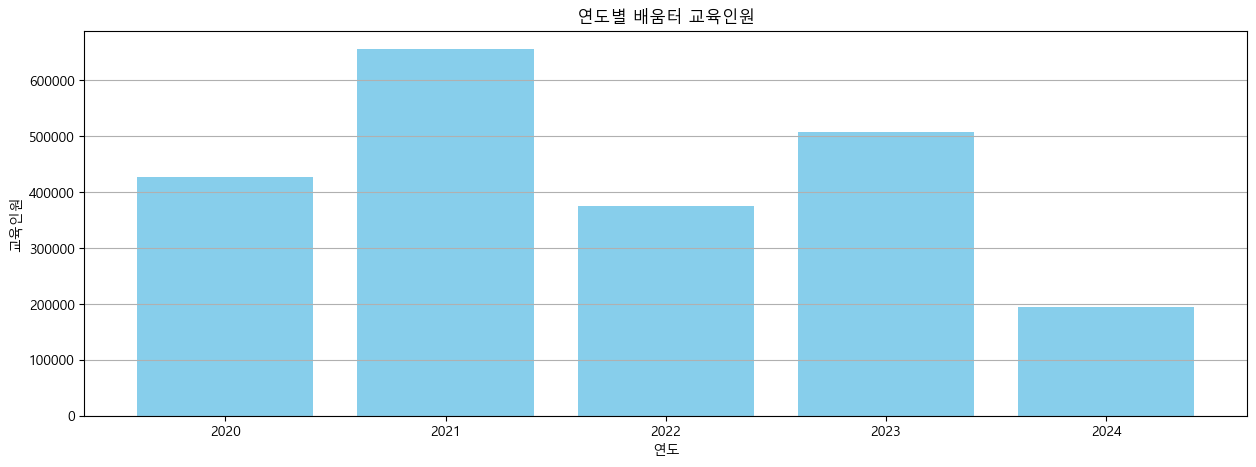

In [40]:
if __name__ == '__main__':
    main()